In [87]:
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

c:\Users\barbe\Desktop\Projects\Job Scraper Project\myenv\Lib\site-packages\transformers\modeling_utils.py:454: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.lo

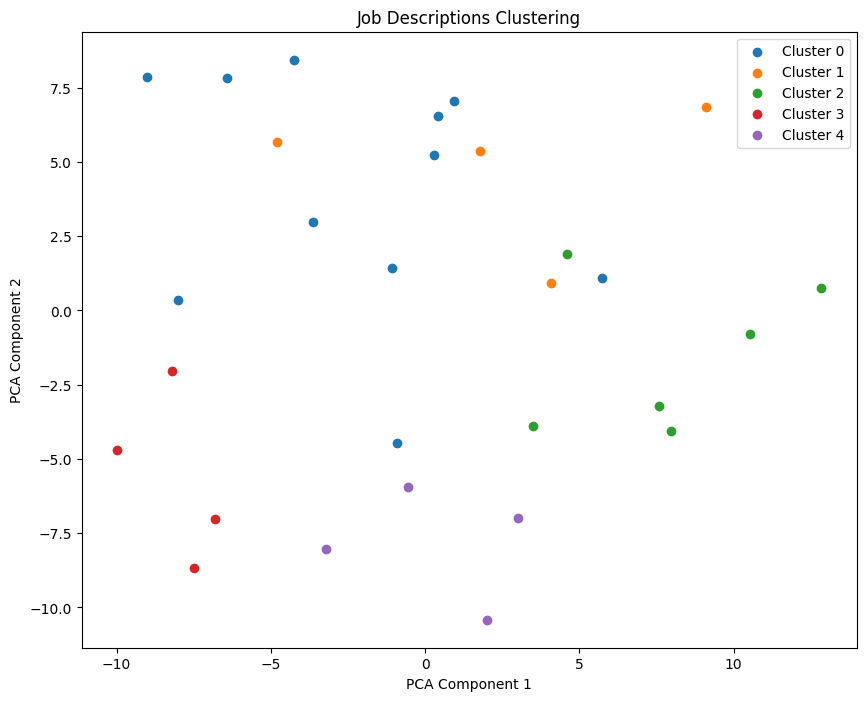

                                      job_description  salary  cluster
0   Software engineer with experience in Python an...  120000        3
1   Data scientist proficient in Python and data a...  110000        3
2   Senior software developer specializing in Java...  130000        2
3   Backend engineer with expertise in Java and Sp...  125000        2
4   Frontend developer skilled in React, JavaScrip...   95000        2
5   Marketing specialist with a focus on digital c...   70000        0
6   SEO analyst experienced in keyword research an...   65000        0
7   Product manager experienced in agile methodolo...   90000        0
8   Project manager skilled in scheduling, budgeti...   85000        0
9   DevOps engineer with proficiency in CI/CD pipe...  115000        4
10  Cloud architect specializing in AWS and distri...  140000        4
11  Data engineer experienced in ETL pipelines and...  125000        4
12  Machine learning engineer skilled in TensorFlo...  130000        3
13  AI

In [88]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

# Sample dataset: Job descriptions and salaries
data = {
    "job_description": [
        "Software engineer with experience in Python and machine learning.",
        "Data scientist proficient in Python and data analysis.",
        "Senior software developer specializing in Java and cloud technologies.",
        "Backend engineer with expertise in Java and Spring framework.",
        "Frontend developer skilled in React, JavaScript, and UI/UX design.",
        "Marketing specialist with a focus on digital campaigns and SEO.",
        "SEO analyst experienced in keyword research and web analytics.",
        "Product manager experienced in agile methodologies and team leadership.",
        "Project manager skilled in scheduling, budgeting, and risk management.",
        "DevOps engineer with proficiency in CI/CD pipelines and AWS.",
        "Cloud architect specializing in AWS and distributed systems.",
        "Data engineer experienced in ETL pipelines and big data technologies.",
        "Machine learning engineer skilled in TensorFlow and PyTorch.",
        "AI researcher with expertise in natural language processing and neural networks.",
        "Graphic designer with a background in Adobe Creative Suite and branding.",
        "UI/UX designer focused on creating user-centered web interfaces.",
        "Content writer experienced in blogging, copywriting, and SEO.",
        "Technical writer specializing in creating user manuals and documentation.",
        "Business analyst skilled in data visualization and stakeholder communication.",
        "Financial analyst experienced in forecasting and financial modeling.",
        "Accountant proficient in QuickBooks and financial reporting.",
        "HR specialist with experience in recruitment and employee engagement.",
        "Customer service representative with a focus on resolving client issues.",
        "Sales representative skilled in B2B sales and client relationship management.",
        "Mobile app developer experienced in Flutter and cross-platform solutions.",
        "Software tester skilled in automated testing and quality assurance.",
        "Cybersecurity analyst with expertise in threat detection and vulnerability management.",
        "IT support specialist experienced in troubleshooting and system maintenance.",
        "Network engineer with a background in configuring and managing enterprise networks."
    ],
    "salary": [
        120000, 110000, 130000, 125000, 95000, 70000, 65000, 90000, 85000, 115000, 
        140000, 125000, 130000, 135000, 60000, 70000, 55000, 60000, 80000, 85000, 
        75000, 60000, 50000, 55000, 110000, 95000, 125000, 65000, 90000
    ]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Load pre-trained BERT model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Compute embeddings for job descriptions
embeddings = model.encode(df['job_description'].tolist(), convert_to_tensor=False)

# Combine embeddings with salary data
features = pd.DataFrame(embeddings)
features['salary'] = df['salary']

features.columns = features.columns.astype(str)

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Perform clustering using KMeans
num_clusters = 5
agglom = AgglomerativeClustering(n_clusters=num_clusters)
clusters = agglom.fit_predict(scaled_features)

# Add cluster labels to the DataFrame
df['cluster'] = clusters

# Visualize clusters using PCA for dimensionality reduction
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(10, 8))
for cluster in range(num_clusters):
    cluster_points = reduced_features[df['cluster'] == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}')

plt.title('Job Descriptions Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

# Print the resulting clusters
print(df)


In [89]:
len(data['job_description'])

29

In [90]:
df[df['cluster'] == 0]

,job_description,salary,cluster
5,Marketing specialist with a focus on digital c...,70000,0
6,SEO analyst experienced in keyword research an...,65000,0
7,Product manager experienced in agile methodolo...,90000,0
8,"Project manager skilled in scheduling, budgeti...",85000,0
14,Graphic designer with a background in Adobe Cr...,60000,0
16,"Content writer experienced in blogging, copywr...",55000,0
18,Business analyst skilled in data visualization...,80000,0
19,Financial analyst experienced in forecasting a...,85000,0
21,HR specialist with experience in recruitment a...,60000,0
26,Cybersecurity analyst with expertise in threat...,125000,0


In [91]:
from sklearn.metrics import silhouette_score

In [92]:
silhouette_avg = silhouette_score(scaled_features, clusters)
silhouette_avg

np.float64(0.05317817592370657)

In [93]:
pd.DataFrame(scaled_features)

,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,384
0,-1.124539,-0.436000,0.488774,1.012679,0.578304,-1.980152,-0.332608,-0.344002,-0.853185,-1.436665,...,0.610392,-0.847010,-0.274613,-0.695226,0.641407,0.030144,0.895378,0.751236,1.286412,0.995571
1,-0.242783,0.122644,0.567535,1.365271,-0.651287,-2.071484,-0.372398,-0.701772,-1.182657,0.950763,...,0.212757,-1.983194,1.819425,-1.747903,0.050740,0.467203,1.018749,1.723913,-1.694370,0.639132
2,-0.736754,1.011558,0.418504,-1.477939,-0.137701,-1.012162,-0.552468,-0.148433,-0.273489,0.298316,...,0.649578,-0.400352,-0.904698,-0.715423,-0.634809,1.416640,-0.923697,0.590978,-0.340558,1.352011
3,-0.602472,0.010364,-0.474073,-0.809941,0.646032,-0.132561,0.005038,-0.196102,-1.132084,-1.177221,...,2.295096,1.150048,-1.033035,1.221306,-0.557394,-1.180376,0.825370,0.318003,0.110132,1.173791
4,-0.053420,-1.136561,0.514668,0.112592,1.082032,-0.359740,-1.034139,1.092590,-0.328662,-0.530881,...,0.710674,-0.545299,-0.343840,0.395151,-0.342930,0.548674,1.558289,1.372465,0.882104,0.104474
5,0.084773,-1.732182,0.040764,-0.501750,0.320303,0.585857,1.116295,0.796733,-0.397665,-0.591536,...,-1.940022,-0.464810,1.446151,-1.641094,0.895050,-0.667091,-1.298007,-0.877097,0.422142,-0.786624
6,0.580899,-0.489289,-2.059345,0.613862,-0.561697,1.081212,1.640092,0.554418,-1.803390,0.069888,...,0.826807,1.167584,1.290923,0.377372,0.340943,1.394168,-0.862118,-1.294831,-0.209529,-0.964844
7,0.356271,0.372904,-0.081992,-0.457237,0.794012,1.049886,0.258518,1.600302,-0.020907,-0.194647,...,-0.924923,1.322698,-1.722267,-0.098072,-1.047391,-1.094609,-1.330267,-0.064341,1.810616,-0.073746
8,0.950207,0.225185,0.472089,0.901801,0.459365,0.311172,0.578901,-1.137475,0.250328,2.414730,...,0.317141,1.388717,-0.758445,-0.678822,-1.362488,-1.122121,-0.163277,-0.946051,-0.383875,-0.251966
9,0.654770,0.659640,0.195165,-0.443396,-0.731119,-1.390551,-1.234357,-0.682702,0.988738,1.637662,...,0.344921,-0.100042,-0.027600,0.403720,2.153934,0.378589,-0.066560,1.070771,-1.099546,0.817352


In [94]:
clusters

array([3, 3, 2, 2, 2, 0, 0, 0, 0, 4, 4, 4, 3, 3, 0, 2, 0, 2, 0, 0, 1, 0,
       1, 1, 2, 4, 0, 1, 0])